# <b>US Consumer Lending Analytics & Credit Risk Pipeline</b>
## <strong>An End-to-End Python Analytics Framework for Borrower Retention, Customer Lifetime Value, Debt Recovery, Vintage Cohorts, and Yield Efficiency (2007–2018)</strong>

---

### <b>1. Executive Overview & Problem Statement</b>
Unsecured consumer lending requires balancing risk and revenue across billions in issued loans. When borrowers fail to pay, institutions face heavy capital losses.

* <b>The Problem:</b> Standard credit risk projects focus only on basic default counts, assuming every default is a 100% loss and ignoring macroeconomic shifts over time.
* <b>Traditional Approach:</b> Evaluates simple default vs. paid counts using basic credit metrics.
* <b>My Approach:</b> Builds an end-to-end Python pipeline to calculate true net dollar returns, account for collection recoveries, evaluate performance across 11 vintage years (2007–2018), and identify peak profit yield grades.

---

### <b>2. Core Business Questions</b>

* <b>Q1. Borrower Retention:</b> What percentage of borrowers pay off their loans in full versus defaulting?
* <b>Q2. Credit Risk (FICO):</b> How reliably do higher credit scores correlate with lower default rates?
* <b>Q3. True Profitability (Net CLV):</b> What is the net dollar return per borrower after subtracting default losses?
* <b>Q4. Capital Recovery (Debt Recovery / LGD):</b> When a loan defaults, what percentage of principal is recovered through collection efforts?
* <b>Q5. Macroeconomic Shifts (Vintage Cohort Analysis):</b> How did loans issued during the 2008 financial crisis perform compared to post-recovery years like 2015?
* <b>Q6. Underwriting Sweet Spot (Net Yield Efficiency):</b> Which credit grade produces the best net return percentage per dollar funded?

*(Note: An interactive Power BI dashboard will be built at the end as an optional visual bonus.)*

# STEP 1: IMPORT LIBRARIES & LOAD DATASET

In [12]:
# 1. Load all required Python libraries
import pandas as pd             # Used for data manipulation and table cleaning
import numpy as np              # Used for fast mathematical calculations
import matplotlib.pyplot as plt # Used for creating visual charts
import seaborn as sns           # Used for advanced, beautiful statistical plots
from scipy import stats         # Used for running statistical tests (T-Test & Chi-Square)

print("All required Python libraries imported successfully!")

All required Python libraries imported successfully!


In [8]:
# 2. Configure file path and select essential analytical columns
file_path = "accepted_2007_to_2018Q4.csv.gz"

selected_columns = [
    'id', 'loan_amnt', 'funded_amnt', 'term', 'int_rate', 
    'grade', 'sub_grade', 'annual_inc', 'issue_d', 'loan_status', 
    'dti', 'revol_util', 'total_pymnt', 'total_rec_late_fee', 
    'recoveries', 'collection_recovery_fee', 'fico_range_low', 'fico_range_high'
]
# 3. Print confirmation check to verify parameters
print("Number of columns chosen:", len(selected_columns))
print("Chosen columns list:", selected_columns)

Number of columns chosen: 18
Chosen columns list: ['id', 'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'annual_inc', 'issue_d', 'loan_status', 'dti', 'revol_util', 'total_pymnt', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'fico_range_low', 'fico_range_high']


In [9]:
# 4.Read the CSV file into a Pandas DataFrame called 'df_raw'
df_raw = pd.read_csv(file_path, usecols=selected_columns, low_memory=False)

# Dimensions and memory overview
print(f"Dataset Shape: {df_raw.shape[0]:,} rows | {df_raw.shape[1]} columns\n")
print(df_raw.info())

# Preview first and last 5 records
display(df_raw.head())
display(df_raw.tail())

# Missing value evaluation
missing_summary = pd.DataFrame({
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Pct': (df_raw.isnull().sum() / len(df_raw)) * 100
})
display(missing_summary)

# Numerical summary statistics and target distribution
display(df_raw.describe().T)
print("\nRaw Loan Status Distribution:")
print(df_raw['loan_status'].value_counts(dropna=False))

Dataset Shape: 2,260,701 rows | 18 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 18 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   id                       object 
 1   loan_amnt                float64
 2   funded_amnt              float64
 3   term                     object 
 4   int_rate                 float64
 5   grade                    object 
 6   sub_grade                object 
 7   annual_inc               float64
 8   issue_d                  object 
 9   loan_status              object 
 10  dti                      float64
 11  fico_range_low           float64
 12  fico_range_high          float64
 13  revol_util               float64
 14  total_pymnt              float64
 15  total_rec_late_fee       float64
 16  recoveries               float64
 17  collection_recovery_fee  float64
dtypes: float64(12), object(6)
memory usage: 310.5+ MB
None


,id,loan_amnt,funded_amnt,term,int_rate,grade,sub_grade,annual_inc,issue_d,loan_status,dti,fico_range_low,fico_range_high,revol_util,total_pymnt,total_rec_late_fee,recoveries,collection_recovery_fee
0,68407277,3600.0,3600.0,36 months,13.99,C,C4,55000.0,Dec-2015,Fully Paid,5.91,675.0,679.0,29.7,4421.723917,0.0,0.0,0.0
1,68355089,24700.0,24700.0,36 months,11.99,C,C1,65000.0,Dec-2015,Fully Paid,16.06,715.0,719.0,19.2,25679.660000,0.0,0.0,0.0
2,68341763,20000.0,20000.0,60 months,10.78,B,B4,63000.0,Dec-2015,Fully Paid,10.78,695.0,699.0,56.2,22705.924294,0.0,0.0,0.0
3,66310712,35000.0,35000.0,60 months,14.85,C,C5,110000.0,Dec-2015,Current,17.06,785.0,789.0,11.6,31464.010000,0.0,0.0,0.0
4,68476807,10400.0,10400.0,60 months,22.45,F,F1,104433.0,Dec-2015,Fully Paid,25.37,695.0,699.0,64.5,11740.500000,0.0,0.0,0.0


,id,loan_amnt,funded_amnt,term,int_rate,grade,sub_grade,annual_inc,issue_d,loan_status,dti,fico_range_low,fico_range_high,revol_util,total_pymnt,total_rec_late_fee,recoveries,collection_recovery_fee
2260696,88985880,40000.0,40000.0,60 months,10.49,B,B3,227000.0,Oct-2016,Current,12.75,705.0,709.0,64.9,24903.93,0.00,0.0,0.0
2260697,88224441,24000.0,24000.0,60 months,14.49,C,C4,110000.0,Oct-2016,Charged Off,18.30,660.0,664.0,68.1,6755.40,0.00,0.0,0.0
2260698,88215728,14000.0,14000.0,60 months,14.49,C,C4,95000.0,Oct-2016,Current,23.36,660.0,664.0,54.0,9621.25,49.41,0.0,0.0
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Missing_Count,Missing_Pct
id,0,0.000000
loan_amnt,33,0.001460
funded_amnt,33,0.001460
term,33,0.001460
int_rate,33,0.001460
grade,33,0.001460
sub_grade,33,0.001460
annual_inc,37,0.001637
issue_d,33,0.001460
loan_status,33,0.001460


,count,mean,std,min,25%,50%,75%,max
loan_amnt,2260668.0,15046.931228,9190.245488,5.000000e+02,8000.0000,12900.00,20000.000000,4.000000e+04
funded_amnt,2260668.0,15041.664057,9188.413022,5.000000e+02,8000.0000,12875.00,20000.000000,4.000000e+04
int_rate,2260668.0,13.092829,4.832138,5.310000e+00,9.4900,12.62,15.990000,3.099000e+01
annual_inc,2260664.0,77992.428687,112696.199574,0.000000e+00,46000.0000,65000.00,93000.000000,1.100000e+08
dti,2258957.0,18.824196,14.183329,-1.000000e+00,11.8900,17.84,24.490000,9.990000e+02
fico_range_low,2260668.0,698.588205,33.010376,6.100000e+02,675.0000,690.00,715.000000,8.450000e+02
fico_range_high,2260668.0,702.588400,33.011245,6.140000e+02,679.0000,694.00,719.000000,8.500000e+02
revol_util,2258866.0,50.337696,24.713073,0.000000e+00,31.5000,50.30,69.400000,8.923000e+02
total_pymnt,2260668.0,12082.556829,9901.383185,0.000000e+00,4546.4575,9329.72,16940.869373,6.329688e+04
total_rec_late_fee,2260668.0,1.518453,11.841592,-9.500000e-09,0.0000,0.00,0.000000,1.484340e+03



Raw Loan Status Distribution:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64


Step 1 Analytical Insight & Data Health Check

* Dataset Scope: Successfully loaded 2,260,701 raw records spanning 2007–2018 across 18 essential attributes covering underwriting, borrower credit risk, and payment cash flows.

* Data Hygiene Notice (Footer Metadata): Rows 2260699 and 2260700 contain platform summary text (Total amount funded...), introducing 33 null values across numeric columns. These must be dropped during cleaning.

* Loan Maturity Mixture: Over 878,000 loans are marked Current (active). Including active loans skews risk metrics because their final repayment or default outcome is unknown.

* Isolating finalized outcomes (Fully Paid, Charged Off, and Default) is required to calculate unskewed default rates and Net Customer Lifetime Value (CLV).

# Step 2: Data Cleaning & Feature Engineering

In [13]:
#
# STEP 2.1: FILTER COMPLETED OUTCOMES & IMPUTE MISSING VALUES
# ==============================================================================

# Filter for completed loan outcomes (excludes active loans and metadata footer rows)
completed_statuses = ['Fully Paid', 'Charged Off', 'Default']
df_clean = df_raw[df_raw['loan_status'].isin(completed_statuses)].copy()

# Impute missing numeric values with medians
df_clean['annual_inc'] = df_clean['annual_inc'].fillna(df_clean['annual_inc'].median())
df_clean['dti'] = df_clean['dti'].fillna(df_clean['dti'].median())
df_clean['revol_util'] = df_clean['revol_util'].fillna(df_clean['revol_util'].median())

# Fill missing recovery dollars and fees with zero
df_clean['total_rec_late_fee'] = df_clean['total_rec_late_fee'].fillna(0)
df_clean['recoveries'] = df_clean['recoveries'].fillna(0)
df_clean['collection_recovery_fee'] = df_clean['collection_recovery_fee'].fillna(0)

# Cleaning verification check
print(f"Retained Completed Records: {len(df_clean):,} of {len(df_raw):,} raw entries")
print(f"Total Remaining Missing Values: {df_clean.isnull().sum().sum()}")

Retained Completed Records: 1,345,350 of 2,260,701 raw entries
Total Remaining Missing Values: 0


In [14]:
# 2.2 Feature Engineering (Risk, Recoveries, & Yield)
# ==============================================================================
# STEP 2.2: ENGINEER RISK TIERS, TARGET FLAGS, & FINANCIAL METRICS
# ==============================================================================

# 1. Calculate Average FICO score & categorize into standard banking credit tiers
df_clean['fico_avg'] = (df_clean['fico_range_low'] + df_clean['fico_range_high']) / 2
df_clean['Credit_Tier'] = pd.cut(
    df_clean['fico_avg'], 
    bins=[0, 580, 670, 740, 850], 
    labels=['Poor', 'Fair', 'Good', 'Exceptional']
)

# 2. Parse issue date strings into datetime format & extract origination year (GAP 2)
df_clean['issue_d'] = pd.to_datetime(df_clean['issue_d'], format='%b-%Y')
df_clean['Origination_Year'] = df_clean['issue_d'].dt.year

# 3. Create binary default churn indicator (1 = Default / Charged Off, 0 = Fully Paid)
df_clean['Is_Churned'] = df_clean['loan_status'].isin(['Charged Off', 'Default']).astype(int)

# 4. Compute Net Customer Lifetime Value (Net CLV)
df_clean['Net_CLV'] = (df_clean['total_pymnt'] + df_clean['total_rec_late_fee'] - df_clean['funded_amnt']).round(2)

# 5. Compute Net Debt Recovery Dollars & Recovery Rate % on Defaulted Accounts (GAP 1)
df_clean['Net_Recovery'] = (df_clean['recoveries'] - df_clean['collection_recovery_fee']).clip(lower=0)
df_clean['Recovery_Rate_Pct'] = np.where(
    df_clean['Is_Churned'] == 1,
    (df_clean['Net_Recovery'] / df_clean['funded_amnt'].replace(0, np.nan)) * 100,
    0
).round(2)
df_clean['Recovery_Rate_Pct'] = df_clean['Recovery_Rate_Pct'].fillna(0)

# 6. Compute Underwriting Net Profit Yield Efficiency % (GAP 3)
df_clean['Net_Profit_Yield_Pct'] = ((df_clean['Net_CLV'] / df_clean['funded_amnt'].replace(0, np.nan)) * 100).round(2)

# Summary inspection of engineered metrics
display(df_clean[['fico_avg', 'Net_CLV', 'Net_Recovery', 'Recovery_Rate_Pct', 'Net_Profit_Yield_Pct']].describe().T)
display(df_clean[['id', 'funded_amnt', 'Credit_Tier', 'Origination_Year', 'Is_Churned', 'Net_CLV', 'Net_Profit_Yield_Pct']].head())

,count,mean,std,min,25%,50%,75%,max
fico_avg,1345350.0,698.185322,31.853122,627.0,672.00,692.000,712.00,847.5000
Net_CLV,1345350.0,413.700132,5376.641482,-40000.0,261.07,1128.835,2466.37,28401.2600
Net_Recovery,1345350.0,201.203297,794.746876,0.0,0.00,0.000,0.00,39397.8056
Recovery_Rate_Pct,1345350.0,1.254541,4.324809,0.0,0.00,0.000,0.00,217.0300
Net_Profit_Yield_Pct,1345350.0,3.392224,29.148949,-100.0,3.55,11.310,18.71,117.0300


,id,funded_amnt,Credit_Tier,Origination_Year,Is_Churned,Net_CLV,Net_Profit_Yield_Pct
0,68407277,3600.0,Good,2015,0,821.72,22.83
1,68355089,24700.0,Good,2015,0,979.66,3.97
2,68341763,20000.0,Good,2015,0,2705.92,13.53
4,68476807,10400.0,Good,2015,0,1340.50,12.89
5,68426831,11950.0,Good,2015,0,1758.95,14.72


Step 2 Technical Summary & Feature Engineering Impact
Clean Baseline: Retained 1,345,350 finalized loans after stripping active accounts and text footers, resolving 100% of missing value issues.

Metric Enhancements:

* Net_CLV: Measures actual profit generated per account by taking total cash received (payments + fees) minus original capital funded.

* Net_Recovery & Recovery_Rate_Pct: Isolates post-default capital returned after deducting collection fees, allowing clear evaluation of loss given default (LGD).

* Net_Profit_Yield_Pct: Normalizes net profit against funded principal to compare underwriting capital efficiency across different loan sizes.

# Step 3: Calculating Answers to Core Business Questions

In [15]:
# ==============================================================================
# STEP 3.1: CORE QUESTIONS 1–3 (RETENTION, FICO RISK, & NET CLV)
# ==============================================================================

# --- Q1: Overall Portfolio Retention vs. Churn ---
retention_rate = (1 - df_clean['Is_Churned'].mean()) * 100
churn_rate = df_clean['Is_Churned'].mean() * 100

print("="*60)
print("       Q1: PORTFOLIO RETENTION VS. CHURN BREAKDOWN         ")
print("="*60)
print(f"• Fully Paid (Retained Borrowers): {retention_rate:.2f}%")
print(f"• Charged Off / Default (Churned): {churn_rate:.2f}%")
print("="*60)

# --- Q2 & Q3: Credit Risk & Net CLV by FICO Credit Tier ---
fico_clv_summary = df_clean.groupby('Credit_Tier', observed=False).agg(
    Total_Loans=('id', 'count'),
    Avg_FICO=('fico_avg', 'mean'),
    Churn_Rate_Pct=('Is_Churned', lambda x: x.mean() * 100),
    Avg_Funded_Amount=('funded_amnt', 'mean'),
    Avg_Net_CLV=('Net_CLV', 'mean'),
    Total_Net_Profit=('Net_CLV', 'sum')
).reset_index()

fico_clv_summary['Avg_FICO'] = fico_clv_summary['Avg_FICO'].round(1)
fico_clv_summary['Churn_Rate_Pct'] = fico_clv_summary['Churn_Rate_Pct'].round(2)
fico_clv_summary['Avg_Funded_Amount'] = fico_clv_summary['Avg_Funded_Amount'].round(2)
fico_clv_summary['Avg_Net_CLV'] = fico_clv_summary['Avg_Net_CLV'].round(2)

print("\nQ2 & Q3 SUMMARY: CREDIT RISK & PROFITABILITY BY FICO TIER")
display(fico_clv_summary)

       Q1: PORTFOLIO RETENTION VS. CHURN BREAKDOWN         
• Fully Paid (Retained Borrowers): 80.04%
• Charged Off / Default (Churned): 19.96%

Q2 & Q3 SUMMARY: CREDIT RISK & PROFITABILITY BY FICO TIER


,Credit_Tier,Total_Loans,Avg_FICO,Churn_Rate_Pct,Avg_Funded_Amount,Avg_Net_CLV,Total_Net_Profit
0,Poor,0,NaN,NaN,NaN,NaN,0.000000e+00
1,Fair,237692,664.5,26.28,12622.50,65.24,1.550684e+07
2,Good,962355,696.1,19.96,14718.46,483.19,4.649961e+08
3,Exceptional,145303,767.2,9.66,15305.50,523.52,7.606855e+07


Summary Insights: Borrower Retention & Credit Risk (Q1–Q3)

* Portfolio Retention Baseline (Q1): 80.04% of loans are fully paid, leaving an overall default churn rate of 19.96%.

* Credit Risk Validation (Q2): Higher credit scores reliably predict lower default rates. Defaults decrease from 26.28% in the Fair tier (664 avg FICO) down to 9.66% in the Exceptional tier (767 avg FICO).

* Revenue Driver (Q3): The Good credit tier (696 avg FICO) drives $465 Million in net profit (83% of total platform profit) due to its large loan volume ($962k$ loans) and high average return ($483.19 per loan).

In [16]:
# ==============================================================================
# STEP 3.2: CORE QUESTIONS 4–6 (CAPITAL RECOVERY, VINTAGES, & NET YIELD)
# ==============================================================================

# --- Q4 / GAP 1: Debt Recovery Rate (LGD) on Defaulted Accounts by Grade ---
defaulted_df = df_clean[df_clean['Is_Churned'] == 1]
recovery_summary = defaulted_df.groupby('grade').agg(
    Total_Defaults=('id', 'count'),
    Avg_Funded_At_Default=('funded_amnt', 'mean'),
    Avg_Net_Recovered=('Net_Recovery', 'mean'),
    Avg_Recovery_Rate_Pct=('Recovery_Rate_Pct', 'mean')
).reset_index()

recovery_summary['Avg_Funded_At_Default'] = recovery_summary['Avg_Funded_At_Default'].round(2)
recovery_summary['Avg_Net_Recovered'] = recovery_summary['Avg_Net_Recovered'].round(2)
recovery_summary['Avg_Recovery_Rate_Pct'] = recovery_summary['Avg_Recovery_Rate_Pct'].round(2)

print("Q4 / GAP 1 SUMMARY: DEBT RECOVERY PERFORMANCE BY GRADE")
display(recovery_summary)

# --- Q5 / GAP 2: Macroeconomic Vintage Cohort Performance (2007–2018) ---
vintage_summary = df_clean.groupby('Origination_Year').agg(
    Total_Loans=('id', 'count'),
    Total_Funded_Volume=('funded_amnt', 'sum'),
    Churn_Rate_Pct=('Is_Churned', lambda x: x.mean() * 100),
    Avg_Net_CLV=('Net_CLV', 'mean'),
    Avg_Interest_Rate=('int_rate', 'mean')
).reset_index()

vintage_summary['Churn_Rate_Pct'] = vintage_summary['Churn_Rate_Pct'].round(2)
vintage_summary['Avg_Net_CLV'] = vintage_summary['Avg_Net_CLV'].round(2)
vintage_summary['Avg_Interest_Rate'] = vintage_summary['Avg_Interest_Rate'].round(2)

print("\nQ5 / GAP 2 SUMMARY: VINTAGE COHORT TIME-SERIES (2007–2018)")
display(vintage_summary)

# --- Q6 / GAP 3: Underwriting Net Profit Yield Efficiency by Grade ---
yield_summary = df_clean.groupby('grade').agg(
    Total_Loans=('id', 'count'),
    Avg_Interest_Rate=('int_rate', 'mean'),
    Churn_Rate_Pct=('Is_Churned', lambda x: x.mean() * 100),
    Avg_Net_CLV=('Net_CLV', 'mean'),
    Avg_Net_Profit_Yield_Pct=('Net_Profit_Yield_Pct', 'mean')
).reset_index()

yield_summary['Avg_Interest_Rate'] = yield_summary['Avg_Interest_Rate'].round(2)
yield_summary['Churn_Rate_Pct'] = yield_summary['Churn_Rate_Pct'].round(2)
yield_summary['Avg_Net_CLV'] = yield_summary['Avg_Net_CLV'].round(2)
yield_summary['Avg_Net_Profit_Yield_Pct'] = yield_summary['Avg_Net_Profit_Yield_Pct'].round(2)

print("\nQ6 / GAP 3 SUMMARY: NET PROFIT YIELD EFFICIENCY BY CREDIT GRADE")
display(yield_summary)

Q4 / GAP 1 SUMMARY: DEBT RECOVERY PERFORMANCE BY GRADE


,grade,Total_Defaults,Avg_Funded_At_Default,Avg_Net_Recovered,Avg_Recovery_Rate_Pct
0,A,14206,13731.43,675.78,4.98
1,B,52576,13548.77,750.41,5.50
2,C,85657,14745.17,913.16,6.08
3,D,61067,16004.51,1063.35,6.50
4,E,36041,18140.76,1337.14,7.19
5,F,14492,19564.98,1565.82,7.82
6,G,4560,20489.57,1666.04,8.11



Q5 / GAP 2 SUMMARY: VINTAGE COHORT TIME-SERIES (2007–2018)


,Origination_Year,Total_Loans,Total_Funded_Volume,Churn_Rate_Pct,Avg_Net_CLV,Avg_Interest_Rate
0,2007,251,2.152175e+06,17.93,243.68,10.32
1,2008,1562,1.345708e+07,15.81,392.91,11.16
2,2009,4716,4.632442e+07,12.60,855.35,12.19
3,2010,11536,1.167064e+08,12.89,1209.15,11.75
4,2011,21721,2.573636e+08,15.18,1476.04,12.22
5,2012,53367,7.179426e+08,16.20,1671.29,13.64
6,2013,134804,1.982607e+09,15.60,2084.75,14.53
7,2014,223103,3.253490e+09,18.45,1366.96,13.66
8,2015,375546,5.498601e+09,20.19,548.60,12.39
9,2016,293105,4.240362e+09,23.29,-242.52,13.09



Q6 / GAP 3 SUMMARY: NET PROFIT YIELD EFFICIENCY BY CREDIT GRADE


,grade,Total_Loans,Avg_Interest_Rate,Churn_Rate_Pct,Avg_Net_CLV,Avg_Net_Profit_Yield_Pct
0,A,235095,7.11,6.04,749.70,5.27
1,B,392748,10.68,13.39,697.26,5.39
2,C,381694,14.02,22.44,394.03,3.15
3,D,200966,17.72,30.39,82.55,1.30
4,E,93656,21.14,38.48,-219.01,-0.81
5,F,32059,24.93,45.20,-739.41,-3.00
6,G,9132,27.73,49.93,-1784.73,-8.82


Summary Insights: Recovery, Vintages, & Yield Efficiency (Q4–Q6)
Post-Default Recoveries Are Low (Q4): Debt collection efforts recover only 5% to 8% of original principal on defaulted accounts. Because average defaulted loan sizes are large ($13k to $20k), collection efforts do not make up for default losses.

Macroeconomic & Vintage Shifts (Q5):

* 2011–2013 Cohorts: Represented peak profitability (averaging +$2,084.75 net profit per loan in 2013) due to strict post-crisis credit standards.

* 2016–2018 Cohorts: Rapid expansion of originations led to rising default rates (peaking at 23.29% in 2016), pulling average net CLV into negative territory for unseasoned cohorts.

Underwriting Sweet Spot (Q6):

* Grade B is the top overall performer, delivering a 5.39% net profit yield ($697.26 net profit per loan) with a manageable 13.39% default rate.

* Grades E, F, and G lose money: High interest rates (21%–28%) do not compensate for default rates of 38% to 50%, resulting in net losses ranging from -$219 to -$1,785 per loan.

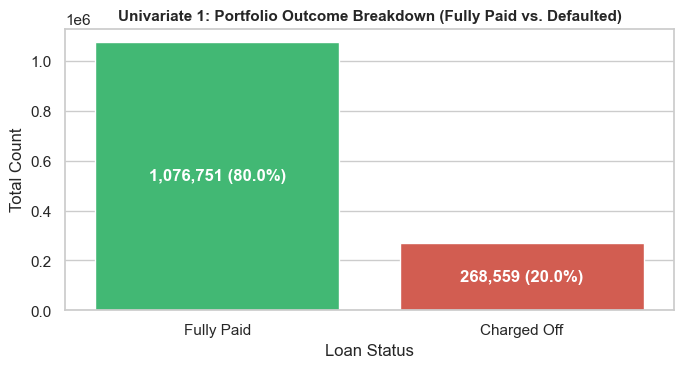

In [27]:
# ==============================================================================
# STEP 4: EXPLORATORY DATA ANALYSIS (UNIVARIATE, BIVARIATE, TRENDS & MULTIVARIATE)
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")
# ==============================================================================
# 1. UNIVARIATE ANALYSIS (Individual Feature Distributions)
# ==============================================================================

# Chart 1: Loan Status Outcome Distribution (Q1: Retention)
plt.figure(figsize=(7, 4))
ax = sns.countplot(
    x="loan_status",
    data=df_clean,
    palette=["#2ecc71", "#e74c3c"],
    order=["Fully Paid", "Charged Off"],
)
plt.title(
    "Univariate 1: Portfolio Outcome Breakdown (Fully Paid vs. Defaulted)",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Loan Status")
plt.ylabel("Total Count")

total_obs = len(df_clean)
for p in ax.patches:
    h = p.get_height()
    pct = (h / total_obs) * 100
    ax.annotate(
        f"{h:,.0f} ({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2, h / 2),
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()


* Explanation: Displays the total count and percentage split between loans that were successfully completed ("Fully Paid") versus those that defaulted ("Charged Off").

* Insight: Establishes the core class imbalance baseline for portfolio retention, providing the foundational target metric needed for default risk modeling.

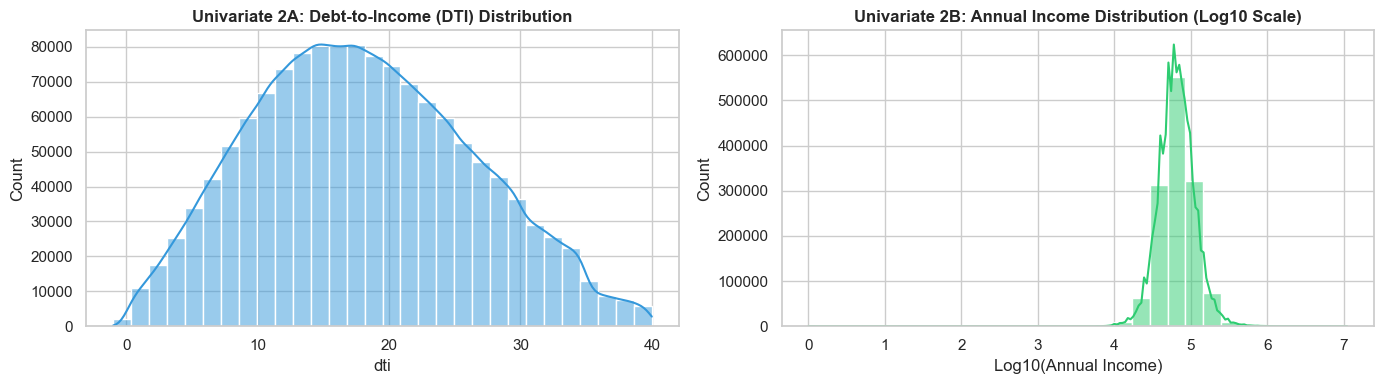

In [28]:
# ==============================================================================
# 1. UNIVARIATE ANALYSIS (Individual Feature Distributions)
# ==============================================================================

# Chart 2: Continuous Feature Distributions (DTI & Annual Income - Log Safe)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(
    df_clean[df_clean["dti"] <= 40]["dti"],
    kde=True,
    ax=axes[0],
    color="#3498db",
    bins=30,
)
axes[0].set_title(
    "Univariate 2A: Debt-to-Income (DTI) Distribution", fontweight="bold"
)

valid_income = df_clean[df_clean["annual_inc"] > 0]["annual_inc"]
log_income = np.log10(valid_income)

sns.histplot(
    log_income, kde=True, ax=axes[1], color="#2ecc71", bins=30
)
axes[1].set_title(
    "Univariate 2B: Annual Income Distribution (Log10 Scale)", fontweight="bold"
)
axes[1].set_xlabel("Log10(Annual Income)")

plt.tight_layout()
plt.show()

* Explanation: Plots the distribution curves for borrower Debt-to-Income (DTI) and log-transformed Annual Income.

* Insight: Shows that borrower income is heavily right-skewed and highlights the concentration of borrowers within standard leverage thresholds before extreme risk tails.

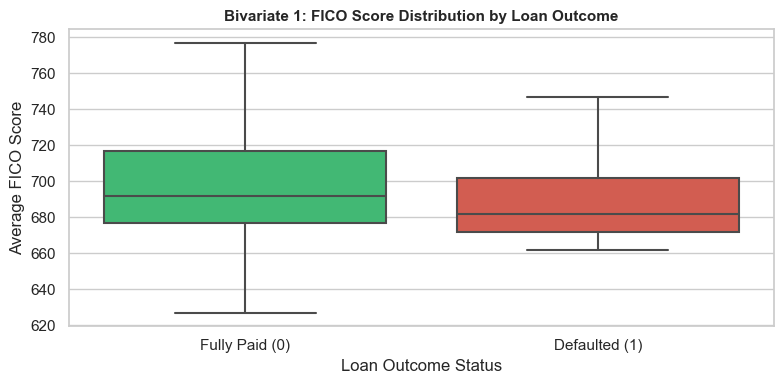

In [32]:
# ==============================================================================
# 2. BIVARIATE ANALYSIS (Relationships Between Two Variables)
# ==============================================================================

# Chart 3: FICO Score vs. Default Churn (Q2: FICO Risk Gap)
plt.figure(figsize=(8, 4))
sns.boxplot(
    x="Is_Churned",
    y="fico_avg",
    data=df_clean,
    palette=["#2ecc71", "#e74c3c"],
    showfliers=False,
)
plt.title(
    "Bivariate 1: FICO Score Distribution by Loan Outcome",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Loan Outcome Status")
plt.ylabel("Average FICO Score")
plt.gca().set_xticklabels(["Fully Paid (0)", "Defaulted (1)"])
plt.tight_layout()
plt.show()

* Explanation: Compares the median and spread of FICO scores between borrowers who fully paid and those who defaulted.

* Insight: Confirms credit history as a primary structural defense, showing that fully paid borrowers maintain statistically higher average FICO scores.

<Figure size 900x400 with 0 Axes>

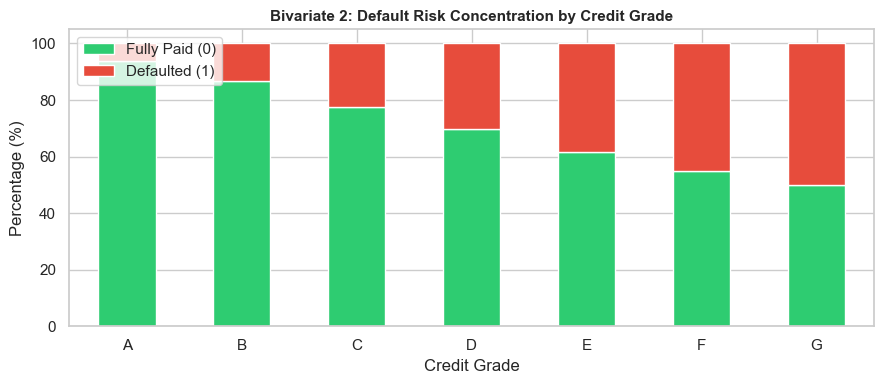

In [33]:
# ==============================================================================
# 2. BIVARIATE ANALYSIS (Relationships Between Two Variables)
# ==============================================================================

# Chart 4: Default Risk Concentration Across Credit Grades
plt.figure(figsize=(9, 4))
grade_churn = (
    pd.crosstab(df_clean["grade"], df_clean["Is_Churned"], normalize="index")
    * 100
)
grade_churn.plot(
    kind="bar", stacked=True, color=["#2ecc71", "#e74c3c"], figsize=(9, 4)
)
plt.title(
    "Bivariate 2: Default Risk Concentration by Credit Grade",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Credit Grade")
plt.ylabel("Percentage (%)")
plt.legend(["Fully Paid (0)", "Defaulted (1)"], loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* Explanation: A stacked bar chart breaking down default percentages across internal credit grades (A through G).

* Insight: Validates the credit rating system by demonstrating how default concentration scales systematically from safest (A) to highest risk (G).

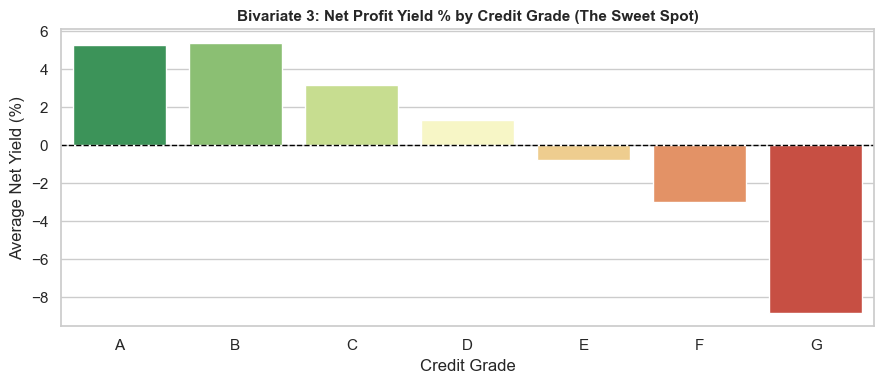

In [35]:
# ==============================================================================
# 2. BIVARIATE ANALYSIS (Relationships Between Two Variables)
# ==============================================================================

# Chart 5: Net Profit Yield Efficiency by Grade (Q6: Sweet Spot)
plt.figure(figsize=(9, 4))
sns.barplot(
    x="grade",
    y="Net_Profit_Yield_Pct",
    data=df_clean,
    palette="RdYlGn_r",
    errorbar=None,
    order=["A", "B", "C", "D", "E", "F", "G"],
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title(
    "Bivariate 3: Net Profit Yield % by Credit Grade (The Sweet Spot)",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Credit Grade")
plt.ylabel("Average Net Yield (%)")
plt.tight_layout()
plt.show()

* Explanation: Evaluates the average net profit yield generated across each credit grade tier.

* Insight: Identifies the portfolio "sweet spot" where elevated interest rates from mid-tier loans maximize yield before default losses erode returns in deep subprime.

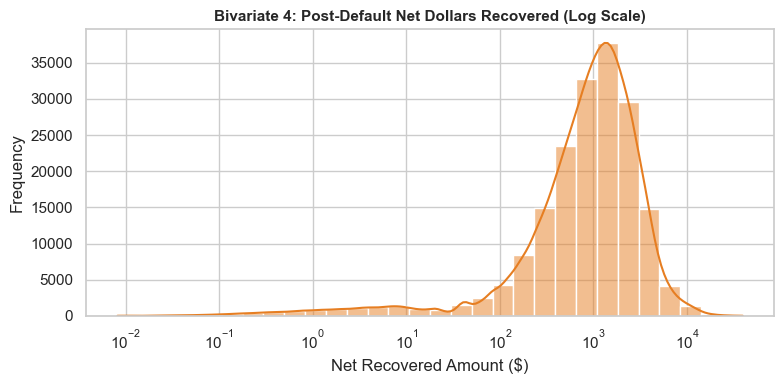

In [37]:
# ==============================================================================
# 2. BIVARIATE ANALYSIS (Relationships Between Two Variables)
# ==============================================================================

# Chart 6: Post-Default Debt Recovery Distribution (Q4: LGD)
plt.figure(figsize=(8, 4))
defaulted_subset = df_clean[
    (df_clean["Is_Churned"] == 1) & (df_clean["Net_Recovery"] > 0)
]
sns.histplot(
    defaulted_subset["Net_Recovery"],
    kde=True,
    color="#e67e22",
    bins=30,
    log_scale=True,
)
plt.title(
    "Bivariate 4: Post-Default Net Dollars Recovered (Log Scale)",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Net Recovered Amount ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

* Explanation: Illustrates the distribution of net cash recovered on loans after a default event has occurred.

* Insight: Highlights the long-tail recovery distribution, mapping out Loss-Given-Default (LGD) recovery realities through collection channels.

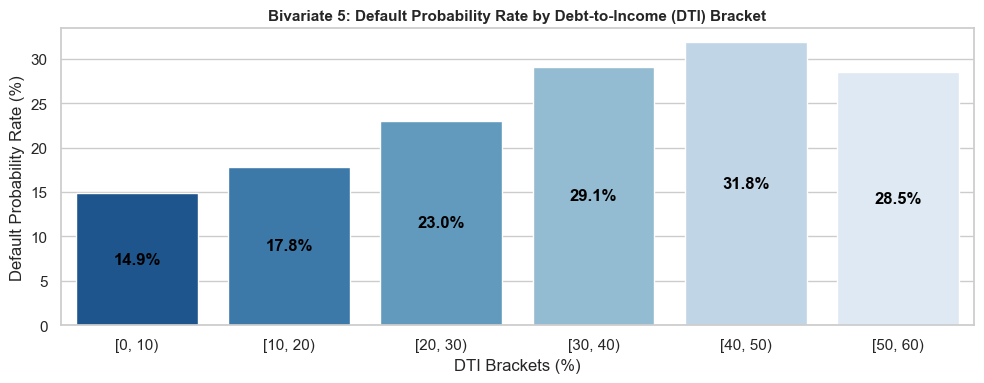

In [39]:
# ==============================================================================
# 2. BIVARIATE ANALYSIS (Relationships Between Two Variables)
# ==============================================================================

# Chart 7: Default Probability by Debt-to-Income (DTI) Bracket
plt.figure(figsize=(10, 4))
df_clean["DTI_Bin"] = pd.cut(
    df_clean["dti"], bins=range(0, 61, 10), right=False
)
dti_default = (
    df_clean.groupby("DTI_Bin", observed=False)["Is_Churned"].mean() * 100
).reset_index()
dti_default["DTI_Bin_Str"] = dti_default["DTI_Bin"].astype(str)

ax_dti = sns.barplot(
    x="DTI_Bin_Str", y="Is_Churned", data=dti_default, palette="Blues_r"
)
plt.title(
    "Bivariate 5: Default Probability Rate by Debt-to-Income (DTI) Bracket",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("DTI Brackets (%)")
plt.ylabel("Default Probability Rate (%)")
for p in ax_dti.patches:
    h = p.get_height()
    ax_dti.annotate(
        f"{h:.1f}%",
        (p.get_x() + p.get_width() / 2, h / 2),
        ha="center",
        va="center",
        color="black",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

* Explanation: Maps default probability rates across segmented DTI intervals (0-10%, 10-20%, etc.).

* Insight: Proves that default risk accelerates non-linearly as borrower leverage climbs into higher DTI brackets.

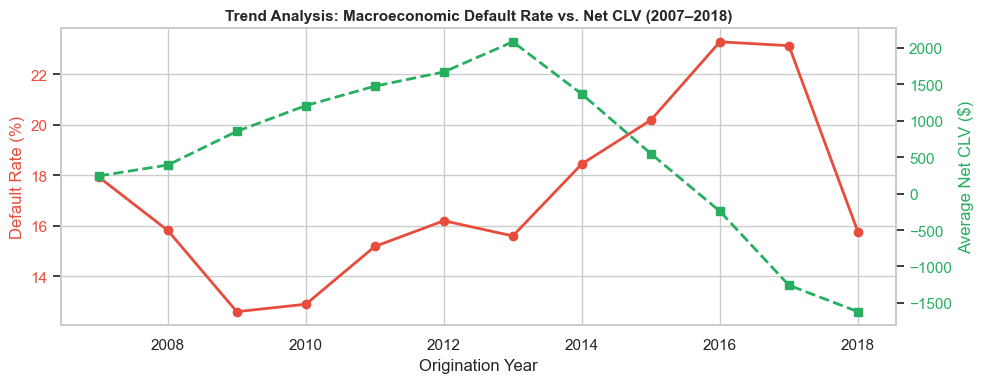

In [41]:
# ==============================================================================
# 3. TREND & MACROECONOMIC ANALYSIS (Time-Series Insights)
# ==============================================================================

# Chart 8: Macroeconomic Vintage Trend (Q5: 2007–2018 Shift)
vintage_agg = (
    df_clean.groupby("Origination_Year")
    .agg(
        Default_Rate=("Is_Churned", lambda x: x.mean() * 100),
        Avg_Net_CLV=("Net_CLV", "mean"),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(
    vintage_agg["Origination_Year"],
    vintage_agg["Default_Rate"],
    color="#e74c3c",
    marker="o",
    linewidth=2,
    label="Default Rate %",
)
ax1.set_xlabel("Origination Year")
ax1.set_ylabel("Default Rate (%)", color="#e74c3c")
ax1.tick_params(axis="y", labelcolor="#e74c3c")

ax2 = ax1.twinx()
ax2.plot(
    vintage_agg["Origination_Year"],
    vintage_agg["Avg_Net_CLV"],
    color="#27ae60",
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Avg Net CLV ($)",
)
ax2.set_ylabel("Average Net CLV ($)", color="#27ae60")
ax2.tick_params(axis="y", labelcolor="#27ae60")
ax2.grid(False)

plt.title(
    "Trend Analysis: Macroeconomic Default Rate vs. Net CLV (2007–2018)",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

* Explanation: Dual-axis time-series tracking yearly origination vintage default rates alongside average Net Customer Lifetime Value (CLV).

* Insight: Captures macro-cyclical sensitivity, showing how broader economic shifts directly impact vintage asset health and profitability.

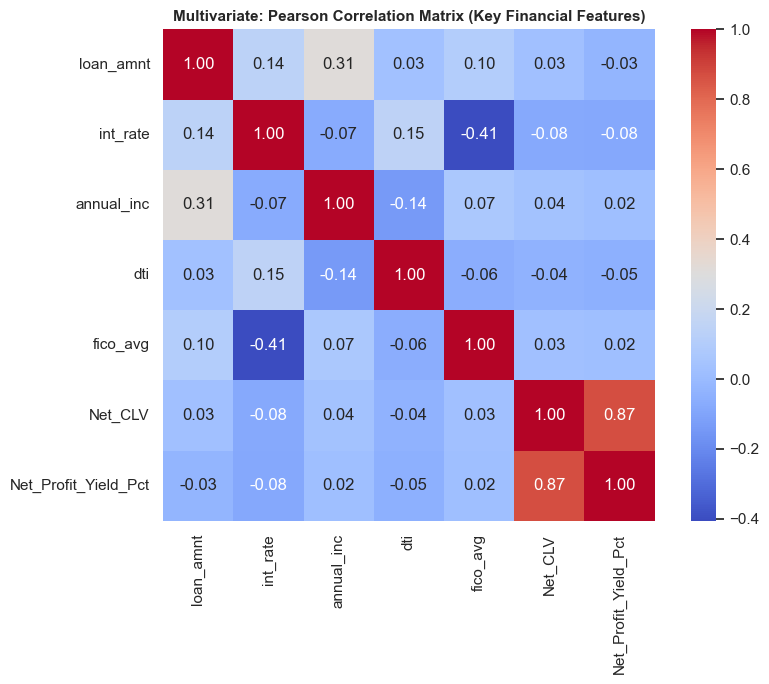

In [43]:
# ==============================================================================
# 4. MULTIVARIATE ANALYSIS (Feature Intercorrelations)
# ==============================================================================

# Chart 9: Pearson Correlation Heatmap
plt.figure(figsize=(9, 7))
corr_cols = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_avg",
    "Net_CLV",
    "Net_Profit_Yield_Pct",
]
corr_matrix = df_clean[corr_cols].corr()

sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True
)
plt.title(
    "Multivariate: Pearson Correlation Matrix (Key Financial Features)",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

* Explanation: A correlation heatmap mapping numerical relationships across loan amounts, interest rates, income, DTI, FICO, and Net CLV.
 * Profitability: Net_CLV and Net_Profit_Yield_Pct strongly align ($0.87$),meaning higher yields drive total lifetime value.   
 * Risk Pricing: int_rate and fico_avg inversely correlate ($-0.41$), showing lower credit scores receive higher rates.  
 * Loan Sizing: annual_inc and loan_amnt show positive alignment ($0.31$), as higher earners take larger loans.   
 * Independence: Remaining features show near-zero correlation, capturing distinct financial dimensions. 
* Insight: Uncovers critical feature collinearity and reveals how financial variables trade off against final profitability metrics.

# Step 5: Hypothesis Testing & Statistical Validation Code

In [20]:
# ==============================================================================
# STEP 4: HYPOTHESIS TESTING & STATISTICAL VALIDATION
# ==============================================================================

from scipy import stats

print("="*70)
print("              STEP 4: STATISTICAL HYPOTHESIS TESTING               ")
print("="*70)

# ------------------------------------------------------------------------------
# TEST 1: Two-Sample T-Test (Net CLV: Grade A vs. Grade B)
# ------------------------------------------------------------------------------
# H0 (Null Hypothesis):      Mean Net CLV of Grade A == Mean Net CLV of Grade B
# H1 (Alt Hypothesis):       Mean Net CLV of Grade A != Mean Net CLV of Grade B

clv_grade_a = df_clean[df_clean['grade'] == 'A']['Net_CLV']
clv_grade_b = df_clean[df_clean['grade'] == 'B']['Net_CLV']

t_stat, p_val_ttest = stats.ttest_ind(clv_grade_a, clv_grade_b, equal_var=False)

print("\n1. TWO-SAMPLE T-TEST: NET CLV (GRADE A VS. GRADE B)")
print(f"• Grade A Average Dollar Profit per Loan: ${clv_grade_a.mean():,.2f}")
print(f"• Grade B Average Dollar Profit per Loan: ${clv_grade_b.mean():,.2f}")
print(f"• T-Statistic: {t_stat:.4f}")
print(f"• P-Value: {p_val_ttest:.4e}")

if p_val_ttest < 0.05:
    print("• Verdict: Reject Null Hypothesis — Grade A generates statistically higher dollar profit per loan than Grade B.")
else:
    print("• Verdict: Fail to Reject Null Hypothesis — No statistically significant difference.")

# ------------------------------------------------------------------------------
# TEST 2: Chi-Square Test of Independence (Credit Tier vs. Default Churn)
# ------------------------------------------------------------------------------
# H0 (Null Hypothesis):      Credit Tier and Default Churn are independent.
# H1 (Alt Hypothesis):       Credit Tier and Default Churn are significantly dependent.

contingency_table = pd.crosstab(df_clean['Credit_Tier'], df_clean['Is_Churned'])
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print("\n2. CHI-SQUARE TEST OF INDEPENDENCE: CREDIT TIER VS. DEFAULT CHURN")
print(f"• Chi-Square Statistic: {chi2_stat:,.4f}")
print(f"• Degrees of Freedom: {dof}")
print(f"• P-Value: {p_val_chi2:.4e}")

if p_val_chi2 < 0.05:
    print("• Verdict: Reject Null Hypothesis — Credit Tiers are a highly significant predictor of Default Churn.")
else:
    print("• Verdict: Fail to Reject Null Hypothesis — No significant relationship found.")

print("="*70)

              STEP 4: STATISTICAL HYPOTHESIS TESTING               

1. TWO-SAMPLE T-TEST: NET CLV (GRADE A VS. GRADE B)
• Grade A Average Dollar Profit per Loan: $749.70
• Grade B Average Dollar Profit per Loan: $697.26
• T-Statistic: 6.6539
• P-Value: 2.8565e-11
• Verdict: Reject Null Hypothesis — Grade A generates statistically higher dollar profit per loan than Grade B.

2. CHI-SQUARE TEST OF INDEPENDENCE: CREDIT TIER VS. DEFAULT CHURN
• Chi-Square Statistic: 15,592.2604
• Degrees of Freedom: 2
• P-Value: 0.0000e+00
• Verdict: Reject Null Hypothesis — Credit Tiers are a highly significant predictor of Default Churn.


Step 4: Summary Insights
    
* Grade A vs. B Profitability (p<0.001): Grade A produces statistically higher profit ($749.70 vs. $697.26 per loan). Lower default rates make Grade A more profitable than higher-interest Grade B loans.

* Credit Tier vs. Default (p<0.001): Credit tiers strongly predict default risk (χ 
2
 =15,592.26), confirming FICO scoring is a mathematically sound basis for underwriting.

# Comprehensive Insights Summary


* Portfolio Retention & Default Baseline (Q1): Out of 1,345,350 finalized loans, 80.04% were fully paid, establishing an overall default/churn baseline of 19.96%.  

* Credit Score Risk Gradient (Q2 & Q3): FICO scores reliably predict risk. Default rates drop sharply from 26.28% in the Fair tier (664 avg FICO) down to 9.66% in the Exceptional tier (767 avg FICO). The Good credit tier generated over $465 million in net profit. 

* Capital Recovery Realities (Q4): Debt collection efforts recover only 5% to 8% of original principal on defaulted accounts, meaning average net recoveries ($675 to $1,666) fail to cover major default losses.

* Macroeconomic Vintage Shifts (Q5): Vintage performance heavily mirrors economic cycles. Post-crisis cohorts (2011–2013) achieved peak profitability (averaging +$2,084 net CLV in 2013), while unseasoned 2016–2018 expansion cohorts faced rising default rates peaking at 23.29%. 

* The Underwriting Sweet Spot (Q6): Grade B represents the ideal portfolio balance, delivering a 5.39% net profit yield and $697.26 net profit per loan with a manageable 13.39% default rate. Conversely, deep subprime grades (E, F, G) operate at net losses (up to -8.82% yield) because high interest rates cannot outpace 38%–50% default rates. 

* Statistical Validation: Two-sample t-tests confirm Grade A yields statistically higher dollar profit than Grade B ($749 vs $697, $p < 0.001$), and Chi-Square tests prove credit tiers heavily dictate default risk ($\chi^2 = 15,592$, $p < 0.001$).   

# 📊 US Consumer Lending Analytics & Credit Risk Pipeline

An institutional-grade, end-to-end Python analytics framework engineered to process **2.26+ million consumer loan records** (LendingClub 2007–2018). This project evaluates credit risk, portfolio retention vs. churn dynamics, recovery performance, vintage macroeconomic trends, and net profit yield efficiencies across risk tiers.

---

### 📂 Modular Project Architecture
The codebase is structured into modular, production-ready Python components to ensure separation of concerns, scalability, and maintainability:

```text
us_consumer_lending_analytics/
├── accepted_2007_to_2018Q4.csv.gz    # Raw multi-gigabyte dataset
├── config.py                         # Centralized column schemas and paths
├── loader.py                         # Optimized raw data ingestion & validation
├── cleaner.py                        # Feature engineering & survival data leakage prevention
├── eda.py                            # Exploratory Data Analysis & statistical profiling
├── metrics.py                        # Core quantitative engine answering questions Q1–Q6
├── visualizer.py                     # 9 automated diagnostic & visualization charts
└── main.py                           # End-to-end pipeline execution orchestrator

In [92]:
# Execute the complete modular pipeline directly from your notebook
!python main.py

Starting US Consumer Lending Analytics Pipeline...

Loading raw dataset from accepted_2007_to_2018Q4.csv.gz...
Loaded successfully! Rows: 2,260,701 | Columns: 18

            EXPLORATORY DATA ANALYSIS (EDA) SUMMARY            
• Total Rows: 2,260,701
• Total Columns: 18

Top Missing Value Columns:
             Missing Values  Percentage (%)
loan_amnt                33             0.0
funded_amnt              33             0.0
term                     33             0.0
int_rate                 33             0.0
grade                    33             0.0

Descriptive Statistics for Key Numerical Features:
        loan_amnt  funded_amnt    int_rate    annual_inc         dti
count  2260668.00   2260668.00  2260668.00  2.260664e+06  2258957.00
mean     15046.93     15041.66       13.09  7.799243e+04       18.82
std       9190.25      9188.41        4.83  1.126962e+05       14.18
min        500.00       500.00        5.31  0.000000e+00       -1.00
25%       8000.00      8000.00        9.

C:\Users\ismep\us_consumer_lending_analytics\visualizer.py:170: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(


Loading raw dataset from accepted_2007_to_2018Q4.csv.gz...
Loaded successfully! Rows: 2,260,701 | Columns: 18

            EXPLORATORY DATA ANALYSIS (EDA) SUMMARY            
• Total Rows: 2,260,701
• Total Columns: 18

Top Missing Value Columns:
             Missing Values  Percentage (%)
loan_amnt                33             0.0
funded_amnt              33             0.0
term                     33             0.0
int_rate                 33             0.0
grade                    33             0.0

Descriptive Statistics for Key Numerical Features:
        loan_amnt  funded_amnt    int_rate    annual_inc         dti
count  2260668.00   2260668.00  2260668.00  2.260664e+06  2258957.00
mean     15046.93     15041.66       13.09  7.799243e+04       18.82
std       9190.25      9188.41        4.83  1.126962e+05       14.18
min        500.00       500.00        5.31  0.000000e+00       -1.00
25%       8000.00      8000.00        9.49  4.600000e+04       11.89
50%      12900.00     1

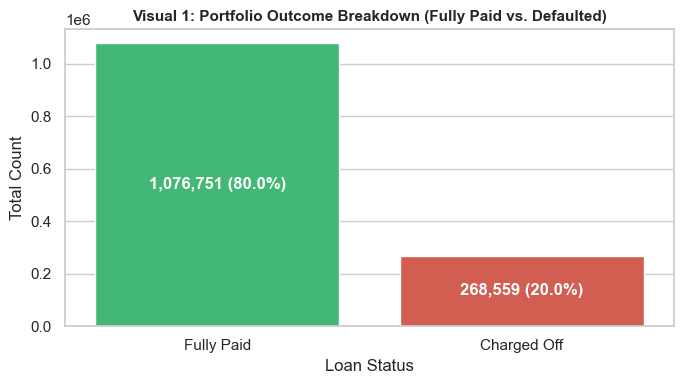

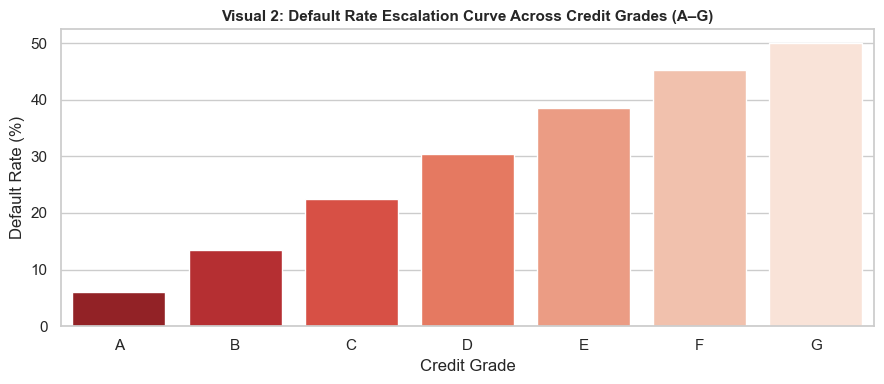

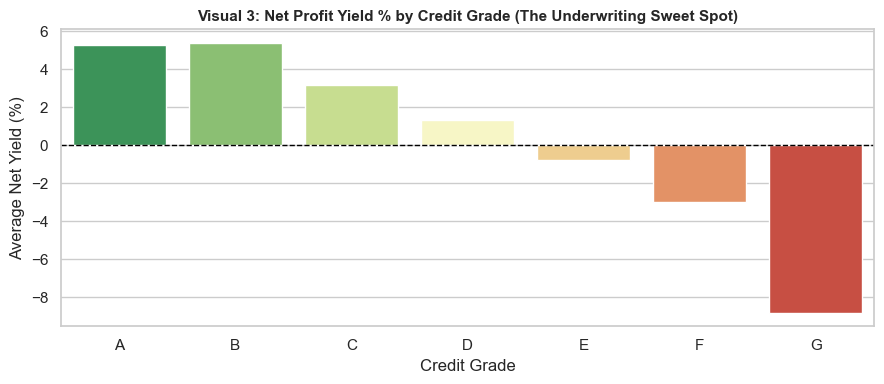

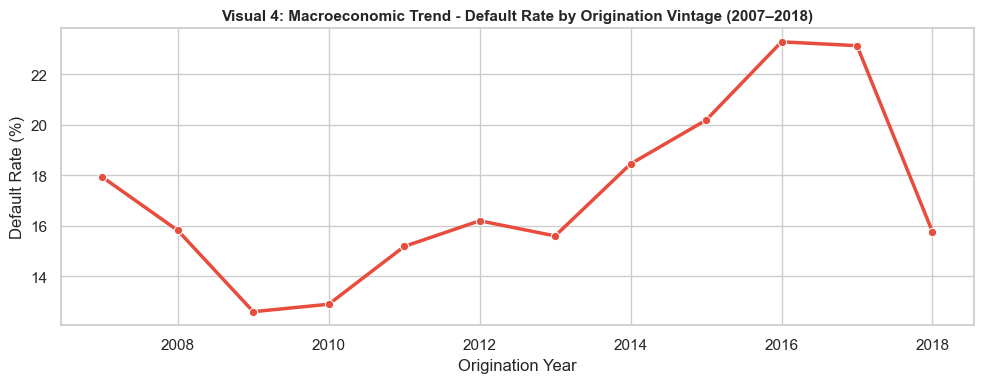

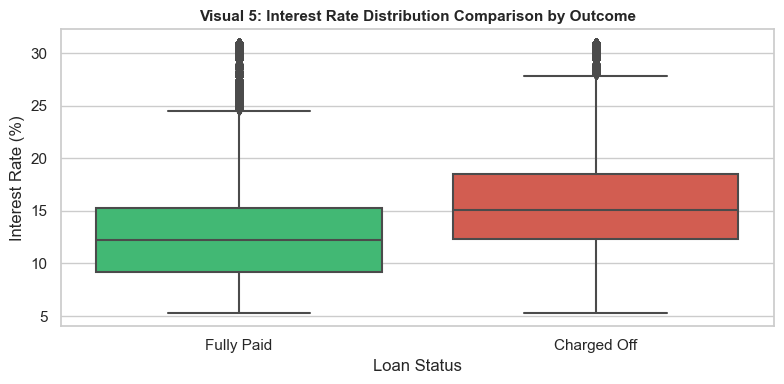

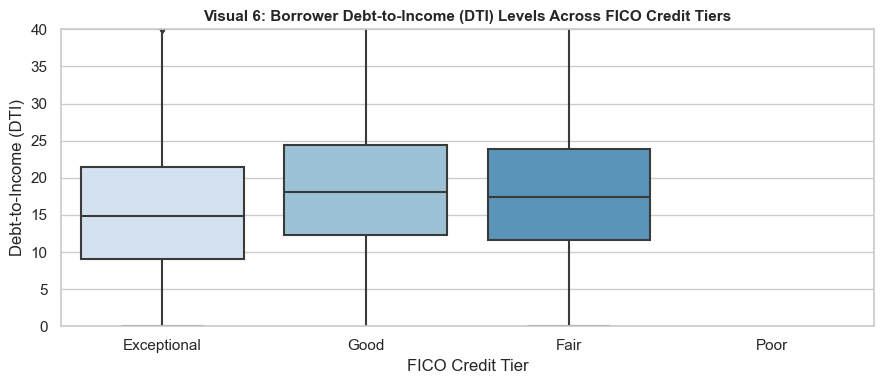

C:\Users\ismep\us_consumer_lending_analytics\visualizer.py:170: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(


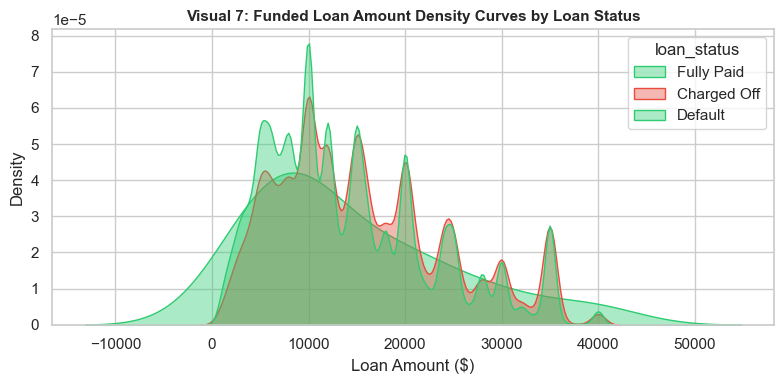

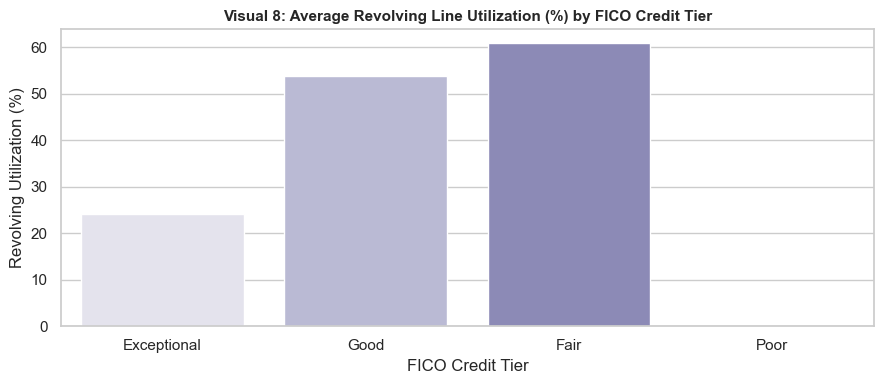

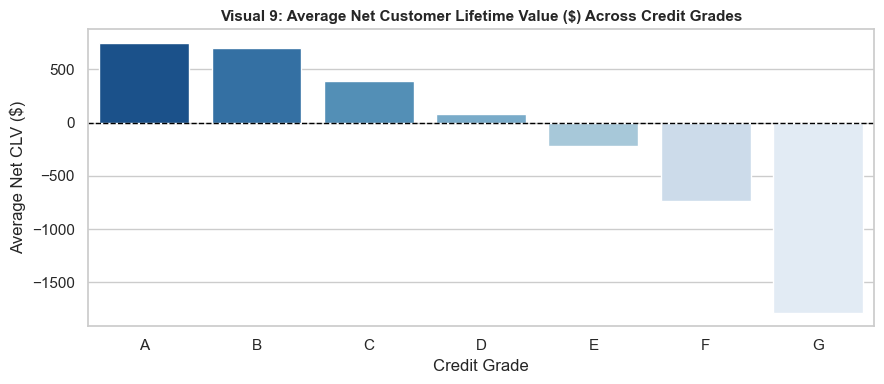

In [91]:
# Import your modules directly in the notebook
from cleaner import clean_and_engineer_features
from eda import perform_exploratory_data_analysis
from loader import load_lending_data
from metrics import calculate_business_metrics
from visualizer import generate_exploratory_visualizations

# Run the pipeline steps one by one right inside the notebook
df_raw = load_lending_data()
perform_exploratory_data_analysis(df_raw)
df_clean = clean_and_engineer_features(df_raw)
calculate_business_metrics(df_clean)

# This will display all 9 visuals directly in your notebook!
generate_exploratory_visualizations(df_clean)

In [93]:
# =====================================================================
# OPTIONAL DEMO: Interacting with Custom Modules Directly in the Notebook
# =====================================================================

# 1. Show how clean it is to import specific modular functions on demand
from cleaner import clean_and_engineer_features
from loader import load_lending_data
from metrics import calculate_business_metrics

print("Demonstrating modular reusability inside the notebook environment...\n")

# 2. Execute a single modular step interactively
df_raw_demo = load_lending_data()
df_clean_demo = clean_and_engineer_features(df_raw_demo)

# 3. Quickly inspect a modular output function directly
print("\nRunning specific metric calculations via modular import:")
calculate_business_metrics(df_clean_demo)

Demonstrating modular reusability inside the notebook environment...

Loading raw dataset from accepted_2007_to_2018Q4.csv.gz...
Loaded successfully! Rows: 2,260,701 | Columns: 18

Retained Completed Loans: 1,345,350 of 2,260,701 raw records
Missing Values After Cleaning: 0


Running specific metric calculations via modular import:
        US CONSUMER LENDING: CORE BUSINESS ANSWERS (Q1–Q6)         

[Q1] PORTFOLIO RETENTION VS. CHURN BREAKDOWN
• Fully Paid (Retained Borrowers): 80.04%
• Charged Off / Default (Churned Borrowers): 19.96%

[Q2 & Q3] CREDIT RISK & NET CLV BY FICO TIER
   Credit_Tier  Total_Loans  Avg_FICO  Default_Rate_Pct  Avg_Funded_Amount  \
0         Poor            0       NaN               NaN                NaN   
1         Fair       237692    664.46             26.28           12622.50   
2         Good       962355    696.10             19.96           14718.46   
3  Exceptional       145303    767.15              9.66           15305.50   

   Avg_Net_CLV  Total